In [1]:
import plotly.express as px
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import os 
pop_info_file = "/scicore/home/muellepi/GROUP/albopictus/info/albo_global_pops_UNSD.txt"

pop_table = pd.read_table(pop_info_file,sep='\t', header=None )
pop_table.index = pop_table[0]
pop_table.columns = ['indv','pop','native_invasive']


baseFolder = "/scicore/home/muellepi/GROUP/202407_Aalbopictus_SNPs_analysis_by_wandrille"

# Analysis of KING (vcftools --relatedness2)

from https://www.kingrelatedness.com/manual.shtml
 
 * negative kinship coefficient : no-relationship + indicate the population structure between the two individuals.
 * Close relatives can be inferred fairly reliably based on the estimated kinship : 
     *  above 0.354 : duplicate/MZ twin
     * [0.177, 0.354] : 1st-degree 
     * [0.0884, 0.177] : 2nd-degree
     * [0.0442, 0.0884] : 3rd-degree


## comparison of `FM_0.70_mD_2_MD_30_FMi_0.35/` and `FM_0.65_mD_2_MD_30_FMi_0.35/`

In [2]:
## primary analysis focus
folder1 = '051_relatedness_computation_with_vcftools_and_plink/FM_0.70_mD_2_MD_30_FMi_0.35/'

## another possible filter setup. We can compare if we get drastically different results
folder2 = '051_relatedness_computation_with_vcftools_and_plink/FM_0.65_mD_2_MD_30_FMi_0.35/'


In [3]:
## NB : from the number of row, this table contains both triangles of the matrix
KING = pd.read_table( os.path.join( baseFolder , folder1 ,  'FM_0.70_mD_2_MD_30_FMi_0.35.relatedness2' ) )
KING.INDV1 = KING.INDV1.str.strip()
KING.INDV2 = KING.INDV2.str.strip()


KING['self'] = KING.INDV1 == KING.INDV2

KING.index = KING.INDV1 + "_" + KING.INDV2

KING.head()

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI,self
invaded@ALKR1_invaded@ALKR1,invaded@ALKR1,invaded@ALKR1,272,0,272,272,0.500000,True
invaded@ALKR1_invaded@ALKR3,invaded@ALKR1,invaded@ALKR3,60,50,272,389,-0.060514,False
invaded@ALKR1_invaded@ALKR5,invaded@ALKR1,invaded@ALKR5,63,66,272,411,-0.101025,False
invaded@ALKR1_invaded@ALSH2,invaded@ALKR1,invaded@ALSH2,27,40,272,264,-0.098881,False
invaded@ALKR1_invaded@ALTI3,invaded@ALKR1,invaded@ALTI3,45,68,272,339,-0.148936,False


In [4]:
KING['relation'] = pd.cut( KING.RELATEDNESS_PHI,
       [-1,0.0442,0.0884,0.177,0.354,1,2],
       labels=["unrelated", "3rd-deg", "2nd-deg",'1st-deg','MZ twin','self'])

KING.loc[KING.self , 'relation'] = 'self'

KING.relation.value_counts() // 2 # divide by 2 because each relation is there twice

relation
unrelated    93051
self           216
2nd-deg         22
3rd-deg         14
1st-deg          8
MZ twin          1
Name: count, dtype: int64

Now, we read the file for the other filter setting

In [5]:
## NB : from the number of row, this table contains both triangles of the matrix
KING2 = pd.read_table( os.path.join( baseFolder , folder2 ,  'FM_0.65_mD_2_MD_30_FMi_0.35.relatedness2' ) )
KING2['self'] = KING2.INDV1 == KING2.INDV2
KING2.index = KING2.INDV1 + "_" + KING2.INDV2
KING2['relation'] = pd.cut( KING2.RELATEDNESS_PHI,
       [-1,0.0442,0.0884,0.177,0.354,1,2],
       labels=["unrelated", "3rd-deg", "2nd-deg",'1st-deg','MZ twin','self'])

KING2.loc[KING2.self , 'relation'] = 'self'

KING2.relation.value_counts() // 2 # divide by 2 because each relation is there twice

relation
unrelated    85044
self           206
2nd-deg         21
3rd-deg          8
1st-deg          4
MZ twin          1
Name: count, dtype: int64

In [6]:
KING.columns

Index(['INDV1', 'INDV2', 'N_AaAa', 'N_AAaa', 'N1_Aa', 'N2_Aa',
       'RELATEDNESS_PHI', 'self', 'relation'],
      dtype='object')

pearson's correlation coefficent between relatedness phi of the two thresholdvcalues: 0.9652.


0.65 threshold,unrelated,3rd-deg,2nd-deg,1st-deg,MZ twin,self
0.70 threshold,,,,,,
unrelated,170066,0,0,0,0,0
3rd-deg,20,8,0,0,0,0
2nd-deg,2,8,34,0,0,0
1st-deg,0,0,8,8,0,0
MZ twin,0,0,0,0,2,0
self,0,0,0,0,0,413


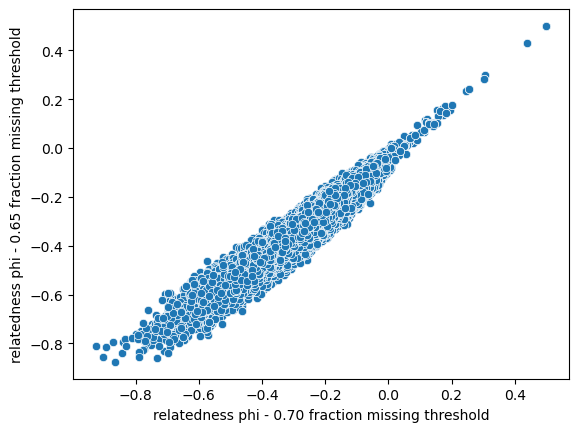

In [7]:
phi1 = KING.loc[ KING2.index , "RELATEDNESS_PHI" ]
relation1 = KING.loc[ KING2.index , "relation" ]
phi2 = KING2.loc[ KING2.index , "RELATEDNESS_PHI" ]
relation2 = KING2.loc[ KING2.index , "relation" ]

sns.scatterplot(x = phi1 , y = phi2)
plt.xlabel( "relatedness phi - 0.70 fraction missing threshold" )
plt.ylabel( "relatedness phi - 0.65 fraction missing threshold" )

print( f"pearson's correlation coefficent between relatedness phi of the two thresholdvcalues: {stats.pearsonr( phi1, phi2 ).statistic:.4f}." )

pd.crosstab(relation1,relation2 , rownames = ["0.70 threshold"] , colnames = ["0.65 threshold"])

The two threshold values yield highly correlated relatedness metric.
    

The 0.70 threshold dataset (ie, the preferred one) seems to designate more putative sibling pairs. 
Given that we will subsequently test each of these putative pairs, it is good that we have something a little bit more on the sensitive side.



## creating "potential kinship groups"

To help Ann-Christin reduce the search space of ML-relate or spagedi,
we will define "potential kinship groups" based on the connected components of a graph where
 * individuals are node
 * we draw an edge between 2 nodes when the relatedness_phi is above 0

We choose 0 for the threshold to have a conservative estimates.

In [8]:
import networkx as nx

tmp = KING.loc[ ( KING.RELATEDNESS_PHI > 0 ) & ( KING.relation != 'self' ) , ["INDV1" , "INDV2"] ]
edges = [ (r.INDV1,r.INDV2) for i,r in tmp.iterrows()]

g = nx.Graph()
g.add_edges_from( edges )
len( g.nodes() )

#potential_kinship_group
with open( "potential_kinship_groups.tsv" , 'w' ) as OUT:
    print( 'INDV' , "potential_kinship_group"  , sep = '\t' , file = OUT)
    for i , cc in enumerate( nx.connected_components(g) ) :
        for n in cc:
            print(n , f"PKG{i}"  , sep = '\t' , file = OUT )


# spagedi - Loiselle's k

* full-sibling : k values of >0.1875
* half-siblings  0.1875>k>0.0938

 from Iacchei 2013 https://doi.org/10.1111/mec.12341

In [9]:
loiselle = pd.read_csv( os.path.join( baseFolder , 'FM_0.70_mD_2_MD_30_FMi_0.35.spagedi_Loiselle_k.csv' )  )
loiselle.head()

,Name i,Name j,Noi,Noj,"Pairwise KINSHIP coefficients (Loiselle et al., 1995)"
0,inv@AAM5,inv@AAM5,1,1,0.050320
1,inv@AAM5,inv@AAM6,1,2,-0.002170
2,inv@AAM5,inv@AAM8,1,3,0.012682
3,inv@AAM5,inv@AT1,1,4,0.006201
4,inv@AAM5,inv@AT2,1,5,0.000068


In [10]:
# let make the ids match

def make_full_ids( short_id ):
    pop , _ , name = short_id.partition('@')
    if pop == 'inv':
        pop = 'invaded'
    elif pop == 'nat' : 
        pop = 'native'
    return pop + "@" + name

loiselle['Name i'] = loiselle['Name i'].apply( make_full_ids )
loiselle['Name j'] = loiselle['Name j'].apply( make_full_ids )

In [11]:
loiselle.index = loiselle['Name i'] + "_" + loiselle['Name j']

In [12]:
common = set( loiselle.index ).intersection( KING.index )
len( common ) , len( loiselle.index )

(5460, 5460)

In [13]:
loiselle.columns

Index(['Name i', 'Name j', 'Noi', 'Noj',
       'Pairwise KINSHIP coefficients (Loiselle et al., 1995)'],
      dtype='object')

<Axes: xlabel='Pairwise KINSHIP coefficients (Loiselle et al., 1995)', ylabel='RELATEDNESS_PHI'>

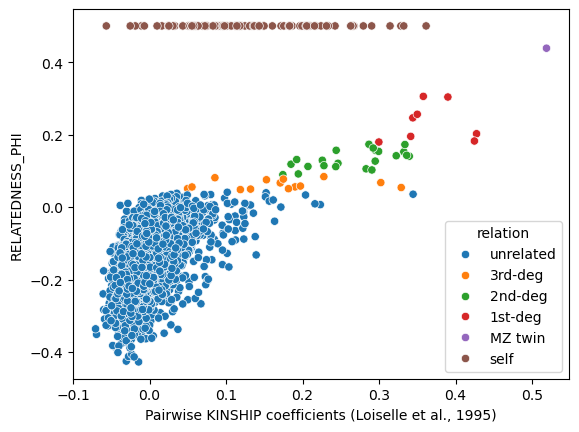

In [14]:
sns.scatterplot( x = loiselle["Pairwise KINSHIP coefficients (Loiselle et al., 1995)"] , 
                 y = KING.loc[ loiselle.index , 'RELATEDNESS_PHI'] , 
                 hue = KING.relation )

In [15]:
loiselle['relation'] = pd.cut( loiselle["Pairwise KINSHIP coefficients (Loiselle et al., 1995)"],
       [-1,0.0938,0.1875,1,2],
       labels=["unrelated", "half-sibling", "sibling",'self'])
loiselle.loc[ loiselle['Name i'] == loiselle['Name j'] , 'relation' ] = 'self'
loiselle['relation'].value_counts()

relation
unrelated       5271
self             104
half-sibling      47
sibling           38
Name: count, dtype: int64

In [16]:
pd.crosstab( loiselle.relation , 
            KING.loc[loiselle.index , "relation"] )

relation,unrelated,3rd-deg,2nd-deg,1st-deg,MZ twin,self
relation,,,,,,
unrelated,5268,3,0,0,0,0
half-sibling,39,6,2,0,0,0
sibling,4,5,20,8,1,0
self,0,0,0,0,0,104


Loiselle's k seems a bit more sensitive than the relatedness phi.



In [17]:
def invert_id( name ):
    ## first splitting. made a bit complex because idsare separated by _ but _ is sometime also in the individual name
    pop1 , mix , name2 = name.split('@')
    name1 , _ , pop2 = mix.rpartition('_') ## relying on the fact that the population does not contain _
    return pop2 + '@' + name2 + '_' + pop1 + '@' + name1


    

In [18]:
## integrating in the KING table
KING.rename(columns = { "relation" : "RELATEDNESS_PHI_relation" } , inplace=True)
KING['loiselle_k'] = np.nan
KING.loc[ loiselle.index , 'loiselle_k' ] = loiselle["Pairwise KINSHIP coefficients (Loiselle et al., 1995)"]


KING['loiselle_k_relation'] = pd.cut( KING.loiselle_k,
       [-1,0.0938,0.1875,1,2],
       labels=["unrelated", "half-sibling", "sibling",'self'])
KING.loc[KING.self , 'loiselle_k_relation' ] = 'self'

KING.head()

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI,self,RELATEDNESS_PHI_relation,loiselle_k,loiselle_k_relation
invaded@ALKR1_invaded@ALKR1,invaded@ALKR1,invaded@ALKR1,272,0,272,272,0.500000,True,self,NaN,self
invaded@ALKR1_invaded@ALKR3,invaded@ALKR1,invaded@ALKR3,60,50,272,389,-0.060514,False,unrelated,NaN,NaN
invaded@ALKR1_invaded@ALKR5,invaded@ALKR1,invaded@ALKR5,63,66,272,411,-0.101025,False,unrelated,NaN,NaN
invaded@ALKR1_invaded@ALSH2,invaded@ALKR1,invaded@ALSH2,27,40,272,264,-0.098881,False,unrelated,NaN,NaN
invaded@ALKR1_invaded@ALTI3,invaded@ALKR1,invaded@ALTI3,45,68,272,339,-0.148936,False,unrelated,NaN,NaN


we want to investigate only the putative relationship flagged by both methods

In [24]:

KING['flagged_by_both_metrics'] = ( ~KING.RELATEDNESS_PHI_relation.isin( ['self','unrelated'] ) ) & ( KING.loiselle_k_relation.isin( ['sibling','half-sibling'] ) ) 
KING.flagged_by_both_metrics.value_counts()                                                                        

flagged_by_both_metrics
False    186582
True         42
Name: count, dtype: int64

NB: in this list there is no self-relation and no doubles

In [25]:
KING.loc[KING.flagged_by_both_metrics,]

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI,self,RELATEDNESS_PHI_relation,loiselle_k,loiselle_k_relation,flagged_by_both_metrics
invaded@BGL6_invaded@BGL9,invaded@BGL6,invaded@BGL9,53,14,258,246,0.049603,False,3rd-deg,0.132042,half-sibling,True
invaded@FRMA11_invaded@FRMA9,invaded@FRMA11,invaded@FRMA9,179,28,374,411,0.156688,False,2nd-deg,0.295326,sibling,True
invaded@FRST1_invaded@FRST10,invaded@FRST1,invaded@FRST10,196,33,398,355,0.172643,False,2nd-deg,0.333852,sibling,True
invaded@AT1_invaded@AT2,invaded@AT1,invaded@AT2,172,27,475,366,0.140309,False,2nd-deg,0.339580,sibling,True
invaded@ILJ10_invaded@ILJ21,invaded@ILJ10,invaded@ILJ21,80,24,383,281,0.048193,False,3rd-deg,0.118698,half-sibling,True
invaded@IBA2_invaded@IBA3,invaded@IBA2,invaded@IBA3,83,13,268,355,0.091493,False,2nd-deg,0.194458,sibling,True
invaded@IMS2_invaded@IUD3,invaded@IMS2,invaded@IUD3,271,0,298,320,0.438511,False,MZ twin,0.518957,sibling,True
invaded@IPA4_invaded@IPA5,invaded@IPA4,invaded@IPA5,151,34,408,318,0.114325,False,2nd-deg,0.227975,sibling,True
invaded@LRE57_invaded@LRE8,invaded@LRE57,invaded@LRE8,134,15,418,443,0.120790,False,2nd-deg,0.246316,sibling,True
invaded@SRB13_invaded@SRB17,invaded@SRB13,invaded@SRB17,189,38,403,332,0.153741,False,2nd-deg,0.299458,sibling,True


In [33]:
KING.to_csv(os.path.join(baseFolder , "052_relatedness_metrics.regrouped.csv") )

## testing putative relationships with ML-relate 

In [31]:
pd.read_csv( os.path.join( baseFolder ,  'FM_0.70_mD_2_MD_30_FMi_0.35.relatedness2.annotated_by_AnnChristin.csv' ) , index_col=0)

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI,self,relation,ML-Relate,hypothesis,alternative,p-value,Distance [km]
0,invaded@ALKR1,invaded@ALKR1,272,0,272,272,0.500000,1,self,NaN,NaN,NaN,NaN,NaN
433,invaded@ALKR3,invaded@ALKR3,389,0,389,389,0.500000,1,self,NaN,NaN,NaN,NaN,NaN
866,invaded@ALKR5,invaded@ALKR5,411,0,411,411,0.500000,1,self,NaN,NaN,NaN,NaN,NaN
1299,invaded@ALSH2,invaded@ALSH2,264,0,264,264,0.500000,1,self,NaN,NaN,NaN,NaN,NaN
1732,invaded@ALTI3,invaded@ALTI3,339,0,339,339,0.500000,1,self,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100454,invaded@TL3,invaded@TL1,126,44,397,352,0.050734,0,3rd-deg,NaN,halfsib,unrelated,NaN,< 20
6064,invaded@BGL6,invaded@BGL9,53,14,258,246,0.049603,0,3rd-deg,NaN,halfsib,fullsib,NaN,< 20
6926,invaded@BGL9,invaded@BGL6,53,14,246,258,0.049603,0,3rd-deg,NaN,halfsib,unrelated,NaN,< 20
31611,invaded@ILJ10,invaded@ILJ21,80,24,383,281,0.048193,0,3rd-deg,NaN,halfsib,fullsib,NaN,< 20
